In [1]:
%run "/Users/hayeonchung/Downloads/CNN/get_cnn_data_v2.ipynb"

Exception: File `'/Users/hayeonchung/Downloads/CNN/get_cnn_data_v2.ipynb'` not found.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models


/opt/miniconda3/envs/ds6001/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [ ]:
x_data, y_data = get_cnn_tensors(
    model_list=model_list,
    scenario="ssp126",
    data_path=data_path,
    var_idx="all",          
    use_anomaly=True,  
    stat="mean",
    st_early=2015, end_early=2024,
    st_late=2055, end_late=2064
)

print(x_data.shape, y_data.shape)


Variable: ['tas', 'tasmax', 'tasmin', 'pr', 'psl', 'sfcWind', 'mrsos'] | Stat: mean | Anomaly: True
Processing Model: CNRM_ESM2-1


/var/folders/6y/d5yr54g90_nbghlfwx83ldb40000gn/T/ipykernel_38309/3874223713.py:96: RuntimeWarning: Mean of empty slice
  v_mean = np.nanmean(v_data[:, b_start:b_end, :, :], axis=1)
/opt/miniconda3/envs/ds6001/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/6y/d5yr54g90_nbghlfwx83ldb40000gn/T/ipykernel_38309/3874223713.py:120: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=0)


Processing Model: MIROC6
Processing Model: MPI-ESM1-2-LR
Processing Model: MRI-ESM2-0
Processing Model: UKESM1-0-LL
(500, 7, 144, 73) (500,)


In [ ]:
X = np.transpose(x_data, (0, 2, 3, 1))  # (N, lat, lon, 1)
y = y_data.astype(np.float32)           # (N, 1)

print("X:", X.shape, "y:", y.shape) # FIX 2: SHOULD BE (500,144,73,7) and (500,1)

X: (500, 144, 73, 7) y: (500,)


Reason for transposing: From get_cnn_tensors, my raw tensor shape was (1000, 1, 144, 73). This means 1000 samples, 1 channel, 144 latitude, 73 longitude. However, TensorFlow expects (1000 ,144, 73, 1) format. This is ensuring that my CNN sees [lat,lon] as the 2D image. 

In [ ]:
# 1) test = 50
X_rem, X_test, y_rem, y_test = train_test_split(
    X, y,
    test_size=50,
    random_state=42,
    stratify=y
)

# 2) val = 50 (from remaining 450)
X_train, X_val, y_train, y_val = train_test_split(
    X_rem, y_rem,
    test_size=50,
    random_state=42,
    stratify=y_rem
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Class balance:", y_train.mean(), y_val.mean(), y_test.mean())


Train: (400, 144, 73, 7) Val: (50, 144, 73, 7) Test: (50, 144, 73, 7)
Class balance: 0.5 0.5 0.5


In [ ]:
def nan_report(name, arr):
    frac = np.isnan(arr).mean()
    print(f"{name}: any NaNs? {np.isnan(arr).any()} | frac NaNs = {frac:.6f}")

nan_report("X_train", X_train)
nan_report("X_val", X_val)
nan_report("X_test", X_test)


X_train: any NaNs? False | frac NaNs = 0.000000
X_val: any NaNs? False | frac NaNs = 0.000000
X_test: any NaNs? False | frac NaNs = 0.000000


## Medium Architecture (~92k parameters)

In [ ]:
lat, lon = X_train.shape[1], X_train.shape[2]

model = models.Sequential([
    layers.Input(shape=(lat, lon, 7)), # FIX #1: SHOULD BE A 7 (lat,lon,7)

    # CNN block (64 filters) with two convs, then pool
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # (lat/2, lon/2, 64)

    # CNN block 32 kernels (conv + pool)
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # (lat/4, lon/4, 32) 

    # CNN block 16 kernels (conv only)
    layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),             
    layers.Dense(50, activation="relu"),
    layers.Dense(10, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 144, 73, 64)    │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 144, 73, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 72, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 72, 36, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 72, 36, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 36, 18, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 36, 18, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 9, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 9, 8)       │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 18, 9, 8)       │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │        14,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,395 (360.92 KB)

 Trainable params: 92,395 (360.92 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=2
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=18,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 247ms/step - accuracy: 0.5575 - loss: 436218848.0000 - val_accuracy: 0.6200 - val_loss: 6105.8076
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 235ms/step - accuracy: 0.7150 - loss: 2686.8284 - val_accuracy: 0.7800 - val_loss: 650.5888
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 234ms/step - accuracy: 0.8075 - loss: 41.8229 - val_accuracy: 0.8200 - val_loss: 0.5431
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 220ms/step - accuracy: 0.7875 - loss: 0.5767 - val_accuracy: 0.7600 - val_loss: 0.5376
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 239ms/step - accuracy: 0.7375 - loss: 943674.1875 - val_accuracy: 0.7800 - val_loss: 0.5214
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.7500 - loss: 0.5535 - val_accuracy: 0.8000 - val_loss: 0.5043
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 235ms/step - accuracy: 0.7575 - loss: 0.5443 - val_accuracy: 0.8000 - val_loss: 0.5012
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 230ms/step - accuracy: 0.7625 - l

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", test_acc)

Test accuracy: 0.9599999785423279


In [ ]:
#.............................................
# SAVE THE TRAINED NETWORK
#.............................................

model.save('my_medium_cnn')

ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=my_medium_cnn.

In [ ]:
model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


array([[0.00975262],
       [0.4864022 ],
       [0.00827976],
       [0.9740996 ],
       [0.00773401],
       [0.03407096],
       [1.        ],
       [0.00808039],
       [0.00807425],
       [1.        ],
       [1.        ],
       [0.98862684],
       [0.00856406],
       [0.00940021],
       [0.00854637],
       [0.00860133],
       [0.0089649 ],
       [0.00835748],
       [0.00800614],
       [1.        ],
       [0.9525127 ],
       [1.        ],
       [0.06252586],
       [1.        ],
       [1.        ],
       [0.5853057 ],
       [0.02996173],
       [1.        ],
       [0.00881526],
       [1.        ],
       [0.99956435],
       [0.63020366],
       [0.00782283],
       [0.02607704],
       [1.        ],
       [1.        ],
       [0.89487576],
       [1.        ],
       [1.        ],
       [0.7675057 ],
       [0.00826496],
       [0.00946754],
       [0.00854653],
       [0.90753573],
       [0.9902431 ],
       [0.12097701],
       [0.95165676],
       [0.009

In [ ]:
y_test

array([0., 1., 0., 1., 0., 0., 1., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0.,
       0., 0., 1., 1., 1., 0., 1., 1., 0., 0., 1., 0., 1., 1., 1., 0., 0.,
       1., 1., 1., 1., 1., 1., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0.],
      dtype=float32)

In [ ]:
model.predict(X_test[0:1]*0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


array([[0.00970602]], dtype=float32)

In [ ]:
# save the model and plot the testing output and the true output in the same plot (scatterplot maybe)

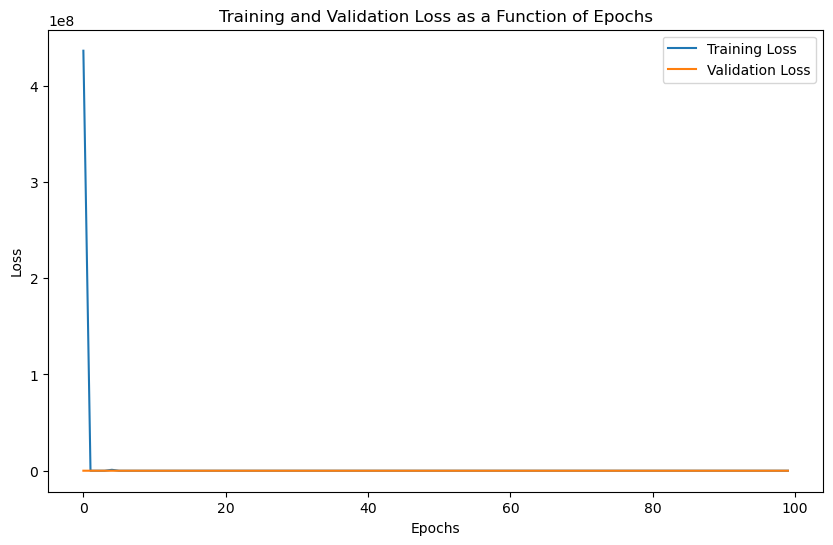

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss as a Function of Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


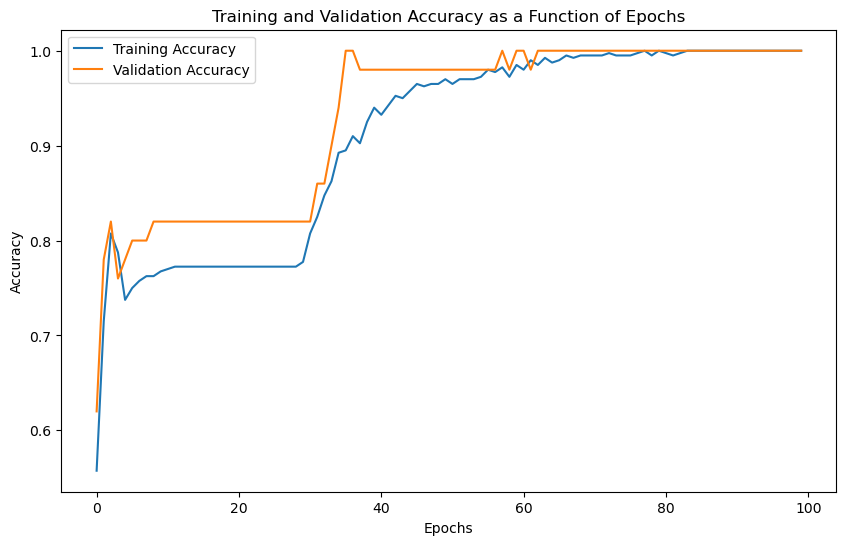

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy as a Function of Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [ ]:
def get_gradients(inputs, model, top_pred_idx=None):
    """Computes the gradients of outputs w.r.t input image.

    Args:
        inputs: 2D/3D/4D matrix of samples
        top_pred_idx: (optional) Predicted label for the x_data
                      if classification problem. If regression,
                      do not include.

    Returns:
        Gradients of the predictions w.r.t img_input
    """
    inputs = tf.cast(inputs, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(inputs)
        
        # Run the forward pass of the layer and record operations
        # on GradientTape.
        preds = model(inputs, training=False)  
        
        # For classification, grab the top class
        if top_pred_idx is not None:
            preds = preds[:, top_pred_idx]
        
    # Use the gradient tape to automatically retrieve
    # the gradients of the trainable variables with respect to the loss.        
    grads = tape.gradient(preds, inputs)
    return grads

def get_integrated_gradients(inputs, model, baseline=None, num_steps=50, top_pred_idx=None):
    """Computes Integrated Gradients for a prediction.

    Args:
        inputs (ndarray): 2D/3D/4D matrix of samples
        baseline (ndarray): The baseline image to start with for interpolation
        num_steps: Number of interpolation steps between the baseline
            and the input used in the computation of integrated gradients. These
            steps along determine the integral approximation error. By default,
            num_steps is set to 50.
        top_pred_idx: (optional) Predicted label for the x_data
                      if classification problem. If regression,
                      do not include.            

    Returns:
        Integrated gradients w.r.t input image
    """
    # If baseline is not provided, start with zeros
    # having same size as the input image.
    if baseline is None:
        input_size = np.shape(inputs)[1:]
        baseline = np.zeros(input_size).astype(np.float32)
    else:
        baseline = baseline.astype(np.float32)

    # 1. Do interpolation.
    inputs = inputs.astype(np.float32)
    interpolated_inputs = [
        baseline + (step / num_steps) * (inputs - baseline)
        for step in range(num_steps + 1)
    ]
    interpolated_inputs = np.array(interpolated_inputs).astype(np.float32)

    # 3. Get the gradients
    grads = []
    for i, x_data in enumerate(interpolated_inputs):
        grad = get_gradients(x_data, model, top_pred_idx=top_pred_idx)     
        grads.append(grad)
    grads = tf.convert_to_tensor(grads, dtype=tf.float32)

    # 4. Approximate the integral using the trapezoidal rule
    grads = (grads[:-1] + grads[1:]) / 2.0
    avg_grads = tf.reduce_mean(grads, axis=0)
    # 5. Calculate integrated gradients and return
    integrated_grads = (inputs - baseline) * avg_grads
    return integrated_grads

def random_baseline_integrated_gradients(inputs, num_steps=50, num_runs=5, top_pred_idx=None):
    """Generates a number of random baseline images.

    Args:
        inputs (ndarray): 2D/3D/4D matrix of samples
        num_steps: Number of interpolation steps between the baseline
            and the input used in the computation of integrated gradients. These
            steps along determine the integral approximation error. By default,
            num_steps is set to 50.
        num_runs: number of baseline images to generate
        top_pred_idx: (optional) Predicted label for the x_data
                      if classification problem. If regression,
                      do not include.      

    Returns:
        Averaged integrated gradients for `num_runs` baseline images
    """
    # 1. List to keep track of Integrated Gradients (IG) for all the images
    integrated_grads = []

    # 2. Get the integrated gradients for all the baselines
    for run in range(num_runs):
        baseline = np.zeros(np.shape(inputs)[1:])
        for i in np.arange(0,np.shape(baseline)[0]):
            j = np.random.choice(np.arange(0,np.shape(inputs)[0]))
            baseline[i] = inputs[j,i]

        igrads = get_integrated_gradients(
            inputs=inputs,
            baseline=baseline,
            num_steps=num_steps,
            top_pred_idx=top_pred_idx)
        integrated_grads.append(igrads)

    # 3. Return the average integrated gradients for the image
    integrated_grads = tf.convert_to_tensor(integrated_grads)
    return tf.reduce_mean(integrated_grads, axis=0)



In [ ]:
sample = 3
IntegratedGrad_zeros_heatmap=get_integrated_gradients(X_test[sample:sample+1],model).numpy()

In [ ]:
# Plotting figures
import matplotlib.pyplot as plt #Main plotting package
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import cartopy.mpl.ticker as cticker


In [ ]:

# Get lat and lon from opening any ds
file_path = data_path + '/CNRM_ESM2-1_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc'
ds = nc.Dataset(file_path)
lat = np.array(ds["lat"][:]) # extracting latitude and longitude grids
lon = np.array(ds["lon"][:])

In [ ]:
X_test = np.transpose(X_test,(0,2,1,3))
IntegratedGrad_zeros_heatmap = np.transpose(IntegratedGrad_zeros_heatmap,(0,2,1,3))
variable = 1

In [ ]:

plt.figure(figsize=(32,4))
ax=plt.subplot(1,4,1,projection=ccrs.PlateCarree())
samplep,lonp = add_cyclic_point(X_test[sample,:,:,variable], coord=lon)
cs = plt.contourf(lonp, lat, samplep, cmap ="coolwarm",levels = np.linspace(-np.max(np.abs(X_test[sample,:,:,variable]),axis=(0,1)),np.max(np.abs(X_test[sample,:,:,variable]),axis=(0,1)),21),extend = 'both')  
cbar = plt.colorbar(cs)   
plt.title('Model Input') 
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.axis('tight')
ax.coastlines()
#plt.legend()
# Define the xticks for longitude
ax.set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
lon_formatter = cticker.LongitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)
# Define the yticks for latitude
ax.set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
lat_formatter = cticker.LatitudeFormatter()
ax.yaxis.set_major_formatter(lat_formatter)

ax=plt.subplot(1,4,2,projection=ccrs.PlateCarree())
samplep,lonp = add_cyclic_point(IntegratedGrad_zeros_heatmap[0,:,:,variable], coord=lon)
cs = plt.contourf(lonp, lat, samplep, cmap ="PuOr_r",levels = np.linspace(-np.max(np.abs(IntegratedGrad_zeros_heatmap[0,:,:,variable]),axis=(0,1)),np.max(np.abs(IntegratedGrad_zeros_heatmap[0,:,:,variable]),axis=(0,1)),21),extend = 'both')  
cbar = plt.colorbar(cs)   
plt.title('Integrated Gradients') 
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.axis('tight')
ax.coastlines()
#plt.legend()
# Define the xticks for longitude
ax.set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
lon_formatter = cticker.LongitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)
# Define the yticks for latitude
ax.set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
lat_formatter = cticker.LatitudeFormatter()
ax.yaxis.set_major_formatter(lat_formatter)
plt.show()

TypeError: 'GeometryCollection' object is not subscriptable

Error in callback <function _draw_all_if_interactive at 0x155935e40> (for post_execute), with arguments args (),kwargs {}:


TypeError: 'GeometryCollection' object is not subscriptable

TypeError: 'GeometryCollection' object is not subscriptable

<Figure size 3200x400 with 3 Axes>

# Adjusting Model

### Large architecture (~200k parameters)

In [ ]:
lat, lon = X_train.shape[1], X_train.shape[2]

model = models.Sequential([
    layers.Input(shape=(lat, lon, 7)), 

    # CNN block (64 filters) with two convs, then pool
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # (lat/2, lon/2, 64)

    # CNN block 32 kernels (conv + pool)
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # (lat/4, lon/4, 32) 

    # CNN block 16 kernels (conv only)
    layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),             
    layers.Dense(50, activation="relu"),
    layers.Dense(10, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 144, 73, 64)    │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 144, 73, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 72, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 72, 36, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 72, 36, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 36, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 36, 18, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 36, 18, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 18, 9, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2592)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 50)             │       129,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,851 (804.11 KB)

 Trainable params: 205,851 (804.11 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=2
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=18,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 174ms/step - accuracy: 0.6050 - loss: 143435936.0000 - val_accuracy: 0.8200 - val_loss: 0.4830
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.8050 - loss: 0.5106 - val_accuracy: 0.9600 - val_loss: 0.4682
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - accuracy: 0.8925 - loss: 0.4934 - val_accuracy: 0.9800 - val_loss: 0.4498
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - accuracy: 0.8975 - loss: 0.4715 - val_accuracy: 0.9600 - val_loss: 0.4239
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.8750 - loss: 0.4396 - val_accuracy: 0.9400 - val_loss: 0.3827
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - accuracy: 0.8825 - loss: 0.3996 - val_accuracy: 0.9400 - val_loss: 0.3394
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - accuracy: 0.8750 - loss: 0.3551 - val_accuracy: 0.9800 - val_loss: 0.2948
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - accuracy: 0.9025 - loss: 0.3118 - 

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", test_acc)

Test accuracy: 1.0


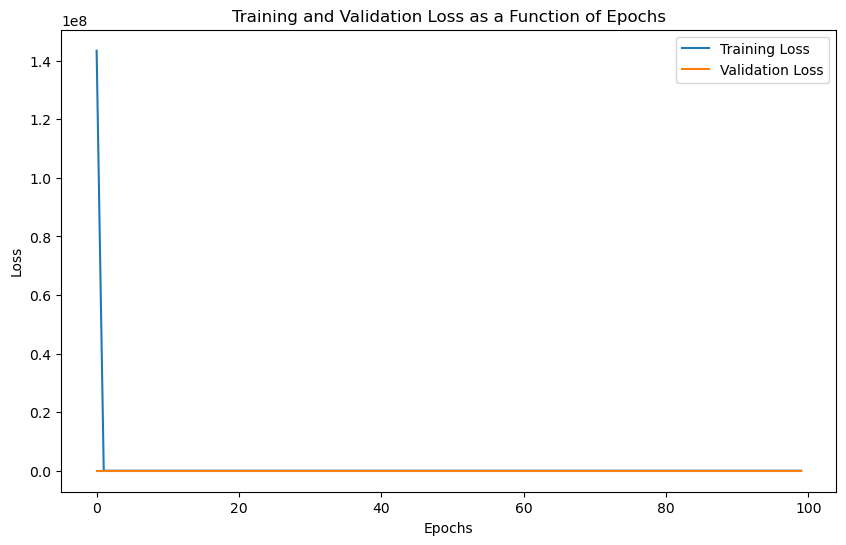

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss as a Function of Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


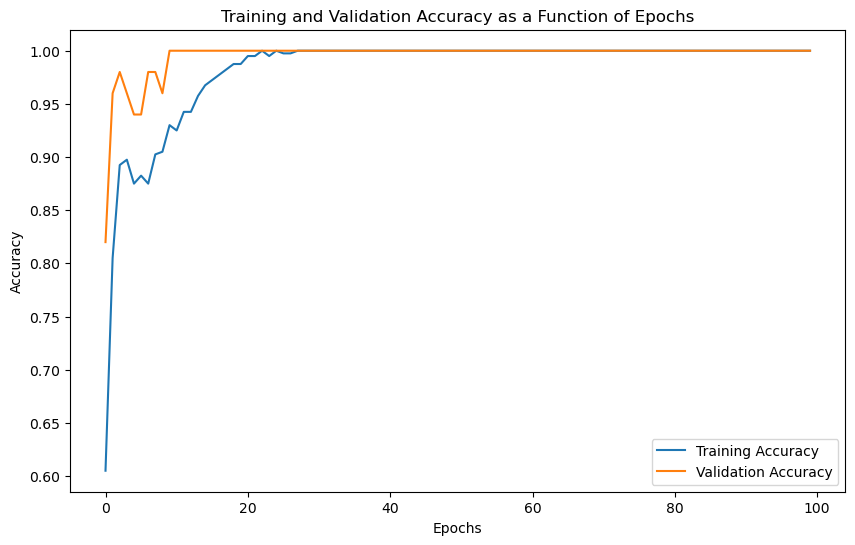

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy as a Function of Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


### Small architecture (~30k parameters)

In [ ]:
lat, lon = X_train.shape[1], X_train.shape[2]

small_model = models.Sequential([
    layers.Input(shape=(lat, lon, 7)),

    layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

small_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 144, 73, 32)    │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 144, 73, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 72, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 72, 36, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 36, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,905 (124.63 KB)

 Trainable params: 31,905 (124.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
small_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=2
)

history = small_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=18,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.4800 - loss: 4411699200.0000 - val_accuracy: 0.5000 - val_loss: 0.5011
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.5000 - loss: 0.5437 - val_accuracy: 0.5000 - val_loss: 0.4969
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.6975 - loss: 0.5402 - val_accuracy: 0.9000 - val_loss: 0.4937
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.8650 - loss: 0.5377 - val_accuracy: 0.8800 - val_loss: 0.4910
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.8300 - loss: 0.5356 - val_accuracy: 0.8400 - val_loss: 0.4887
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.8175 - loss: 0.5336 - val_accuracy: 0.8200 - val_loss: 0.4867
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.8100 - loss: 0.5318 - val_accuracy: 0.8200 - val_loss: 0.4847
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8075 - loss: 0.5301 - val_acc

In [ ]:
test_loss, test_acc = small_model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", test_acc)

Test accuracy: 0.8799999952316284


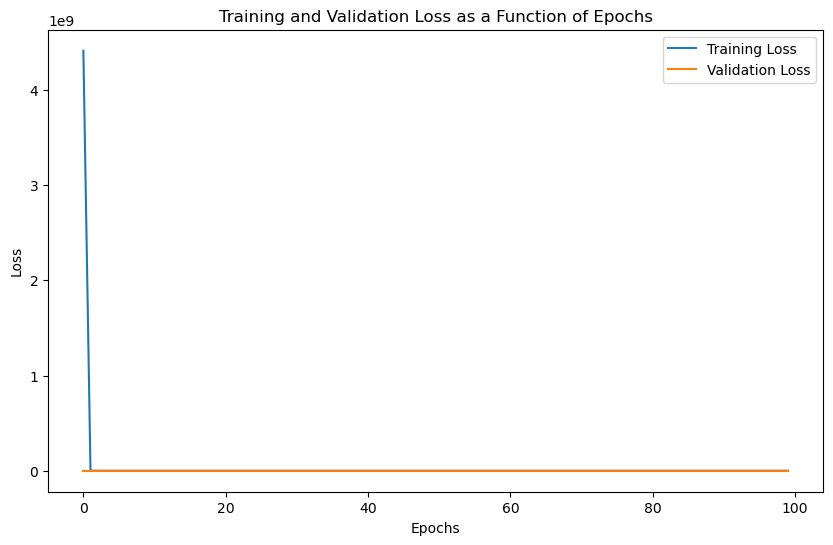

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss as a Function of Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


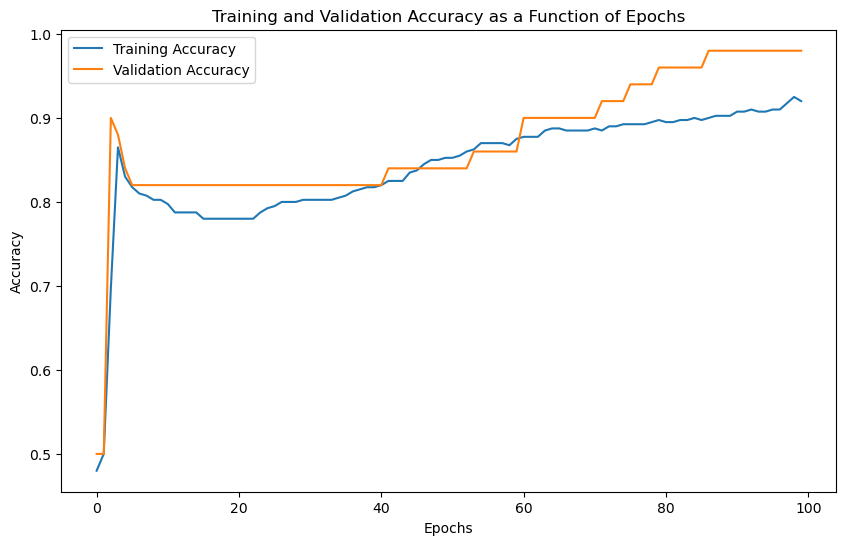

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy as a Function of Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
